## Description
We want to identify TFs that their activity within the differentiation trajectory of major cell type population changes in aging. 
Assuming that differentiation is a continous variable, we seek to identify TFs, which the association of their activity with trajectory changes with aging. 
- Challenge 1: how to label cells with continous value for differentiation without cell type labeling
- Challenge 2: do we have linear trajectory from naive to effector or branching: naive -> memory vs effector

- option 1: define naive markers, and select 10 choice of single cells with top quantile cells
- option 2: automated/global trajectories
    - cluster labels should be comparable between groups of samples -> to interpret what TF act change means

- protocol:
    - use only those donor-age-condition-cell type with sufficient single cell counts
    - within group and between group consideration: the association of tf activity with trajectory is within while the factor of age is between
    - probably a meta analysis to collect the evidence

# Imports

In [1]:
!cd ../ && bash env.sh 
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams["font.family"] = "Arial"
main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from hiara import retrieve_feature_data, retrieve_sig_stats

from hiara import PRIOR_DIR, PLOTS_DIR, CLOCKS_DIR, DATA_DIR, CELL_TYPES, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, AGING_COHORTS
from hiara import retrieve_adata, retrieve_net, retrieve_net_consensus
from hiara import get_config, OUTPUT_DIR
from grn_benchmark.src.helper import load_env
env = load_env()
TASK_GRN_INFERENCE_DIR = env['TASK_GRN_INFERENCE_DIR']
to_save = f'{PLOTS_DIR}/umap/'
os.makedirs(to_save, exist_ok=True)

bash: env.sh: No such file or directory


# DPT with marker scores

In [2]:
from hiara.src.trajectory_analysis.helper import (load_sc_data, compute_dpt, dpt_marker_correlation, annotate)
dataset = 'CXCL9'
cell_type = 'CD8T'

if True:
    adata = load_sc_data(dataset, cell_type, test_mode=True, min_cells_threshold=100)
else:
    adata = ad.read_h5ad(f"{DATA_DIR}/sc/test_traj_data.h5ad")

Loading data for dataset=CXCL9, cell_type=CD8T
Loading data...


TEST MODE: Selecting only 10 donors for testing...
TEST MODE: Selecting only 10 donors for testing...

=== Checking donor_age samples (min threshold: 100 cells) ===
Total donor_age samples: 7
Passing samples: 7 (>= 100 cells)
Failing samples: 0 (< 100 cells)

=== Checking donor_age samples (min threshold: 100 cells) ===
Total donor_age samples: 7
Passing samples: 7 (>= 100 cells)
Failing samples: 0 (< 100 cells)


In [3]:
annotate(adata)
compute_dpt(adata, leiden_resolution=10) # save adata for visualization and downstream analysis

Group CD8T_AG1_RPMI_Donor 2: number of clusters = 72, root cluster = 5 (mean naive score = 0.561)
Group CD8T_AG1_RPMI + ruxolitinib_Donor 4: number of clusters = 62, root cluster = 52 (mean naive score = 0.562)
Group CD8T_AG1_RPMI + ruxolitinib_Donor 4: number of clusters = 62, root cluster = 52 (mean naive score = 0.562)
Group CD8T_AG10_LPS + ruxolitinib_Donor 5: number of clusters = 71, root cluster = 22 (mean naive score = 0.534)
Group CD8T_AG10_LPS + ruxolitinib_Donor 5: number of clusters = 71, root cluster = 22 (mean naive score = 0.534)
Group CD8T_AG11_LPS + ruxolitinib_Donor 6: number of clusters = 78, root cluster = 69 (mean naive score = 0.536)
Group CD8T_AG11_LPS + ruxolitinib_Donor 6: number of clusters = 78, root cluster = 69 (mean naive score = 0.536)
Group CD8T_AG11_LPS_Donor 4: number of clusters = 65, root cluster = 62 (mean naive score = 0.495)
Group CD8T_AG11_LPS_Donor 4: number of clusters = 65, root cluster = 62 (mean naive score = 0.495)
Group CD8T_AG12_LPS_Donor 

AnnData object with n_obs × n_vars = 20575 × 15688
    obs: 'dataset', 'donor_id', 'age', 'sex', 'batch_info', 'pool_id', 'donor_letter', 'treatment_id', 'condition', 'donor_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Major_CT', 'Sub_CT', 'cell_type', 'group_id', 'naive_score', 'proliferating_score', 'central_memory_score', 'effector_memory_score', 'dpt', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'log1p'
    layers: 'counts'


Correlation Summary:
Naive score - Mean corr: -0.721 (Expected: negative)
Effector score - Mean corr: 0.628 (Expected: positive)
Significant donors (p<0.05) for naive: 28/28
Significant donors (p<0.05) for effector: 28/28


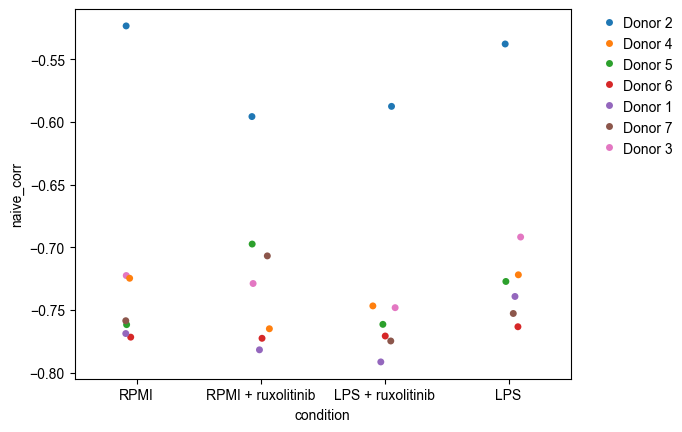

In [18]:
# - corr dpt with marker scores
corr_df = dpt_marker_correlation(adata)
sns.stripplot(data=corr_df, x='condition', y='naive_corr', hue='donor_id')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

(1095, 15688)


<Axes: xlabel='naive_score', ylabel='dpt'>

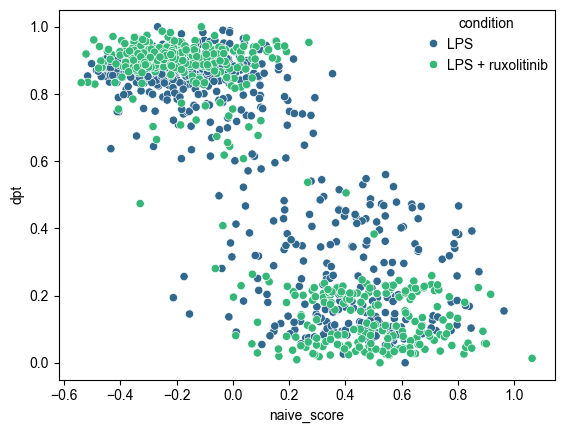

In [42]:
adata_sub = adata[(adata.obs['condition'].isin(['LPS + ruxolitinib', 'LPS'])) & (adata.obs['donor_id'].isin(['Donor 3']))]
print(adata_sub.shape)
sns.scatterplot(data=adata_sub.obs, x='naive_score', y='dpt', palette='viridis', hue='condition')


In [ ]:
corr_out_file= f"{OUTPUT_DIR}/trajectory_analysis/dpt_marker_correlation_{dataset}_{cell_type}.csv"
corr_df.to_csv(corr_out_file, index=False)

# TF act with dpt

In [4]:
from hiara.src.trajectory_analysis.helper import compute_tf_act, tfa_dpt_association, write_traj_stats, compute_tfa_dpt_association
compute_tf_act(adata)
corr_adata = compute_tfa_dpt_association(adata)

Computing TF activities using ULM...
Computing TF-DPT correlations for 432 TFs across 28 groups...
Computing TF-DPT correlations for 432 TFs across 28 groups...


In [7]:
from hiara import associate_with_condition
stats_condition = associate_with_condition(
    corr_adata, 
    config=get_config(dataset)
)

In [11]:
stats_condition.sort_values('p_value_adj')

,gene,p_value,slope,ctrl,condition,p_value_adj,age_group,dataset,comparison
397,ZNF652,1.169696e-20,-0.097965,RPMI,LPS,5.053088e-18,All age groups,CXCL9,LPS (ctr: RPMI)
194,NR4A3,2.789073e-07,0.249115,RPMI,LPS,6.024398e-05,All age groups,CXCL9,LPS (ctr: RPMI)
376,ZNF507,3.695625e-06,0.053098,RPMI,LPS,5.321700e-04,All age groups,CXCL9,LPS (ctr: RPMI)
62,ELF1,9.851761e-05,0.166782,RPMI,LPS,1.063990e-02,All age groups,CXCL9,LPS (ctr: RPMI)
371,ZNF451,7.044340e-05,-0.058688,RPMI,RPMI + ruxolitinib,1.521577e-02,All age groups,CXCL9,Ruxolitinib (ctr: RPMI)
...,...,...,...,...,...,...,...,...,...
81,FOXO1,9.917340e-01,-0.000244,RPMI,RPMI + ruxolitinib,9.940350e-01,All age groups,CXCL9,Ruxolitinib (ctr: RPMI)
146,MAFF,9.946359e-01,0.000168,LPS,LPS + ruxolitinib,9.946359e-01,All age groups,CXCL9,Ruxolitinib (ctr: LPS)
217,RELB,9.940921e-01,-0.000141,LPS,LPS + ruxolitinib,9.946359e-01,All age groups,CXCL9,Ruxolitinib (ctr: LPS)
42,CREB3,9.946375e-01,-0.000152,RPMI,RPMI + ruxolitinib,9.946375e-01,All age groups,CXCL9,Ruxolitinib (ctr: RPMI)


In [ ]:
results = tfa_dpt_association(adata, association='condition')
# write_traj_stats(results, dataset, cell_type)

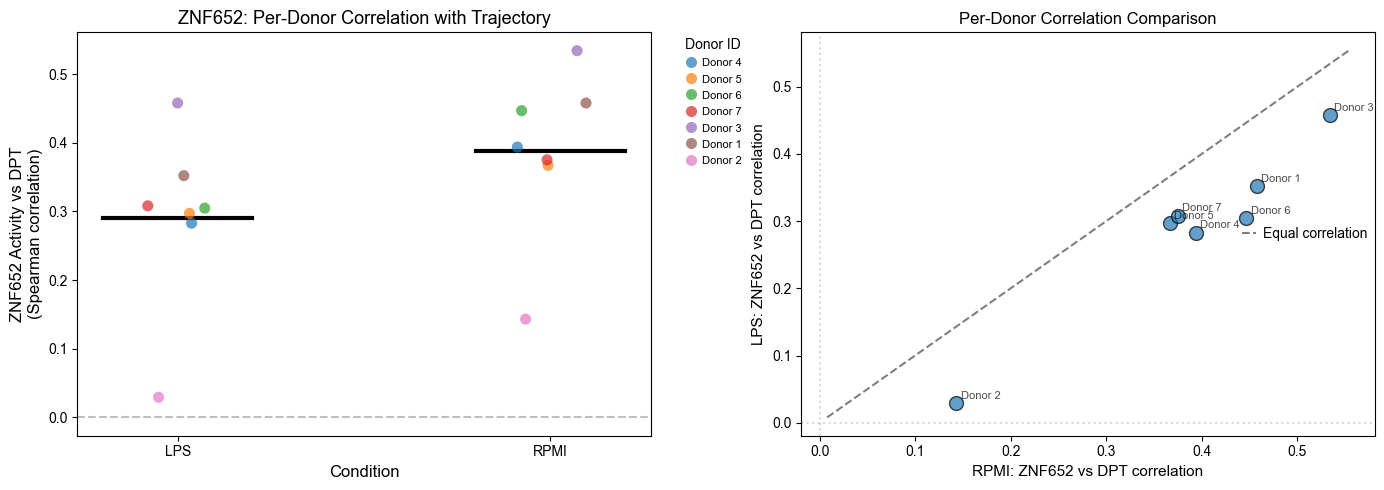


=== ZNF652 Activity vs DPT Correlation Summary ===
          correlation                pval          
                 mean       std      mean       std
condition                                          
LPS          0.290384  0.129539  0.050871  0.134591
RPMI         0.388349  0.122687  0.000001  0.000004

Correlation change (LPS - RPMI):
-0.0979650109004257


In [12]:
# tf act changed its association with DPT along trajectory between LPS and RPMI
from scipy.stats import spearmanr

tf = 'ZNF652'
conditions = ['LPS', 'RPMI']

def plot_tf_dpt_correlation(adata, tf, conditions):
    # Calculate per-donor correlations
    correlations = []
    for condition in conditions:
        adata_cond = adata[adata.obs['condition'] == condition]
        
        for donor_id in adata_cond.obs['donor_id'].unique():
            adata_donor = adata_cond[adata_cond.obs['donor_id'] == donor_id]
            
            if adata_donor.n_obs < 10:  # Skip if too few cells
                continue
            
            tf_activity = adata_donor.obsm['score_ulm'][tf].values
            dpt = adata_donor.obs['dpt'].values
            
            # Calculate Spearman correlation
            corr, pval = spearmanr(dpt, tf_activity)
            
            correlations.append({
                'donor_id': donor_id,
                'condition': condition,
                'correlation': corr,
                'pval': pval,
                'n_cells': adata_donor.n_obs
            })

    corr_df = pd.DataFrame(correlations)

    # Plot 1: Stripplot comparing correlations between conditions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Stripplot
    ax = axes[0]
    sns.stripplot(data=corr_df, x='condition', y='correlation', hue='donor_id', 
                ax=ax, size=8, alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel(f'{tf} Activity vs DPT\n(Spearman correlation)', fontsize=12)
    ax.set_xlabel('Condition', fontsize=12)
    ax.set_title(f'{tf}: Per-Donor Correlation with Trajectory', fontsize=13)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Donor ID', fontsize=8)

    # Calculate mean correlations per condition
    mean_corrs = corr_df.groupby('condition')['correlation'].mean()
    for i, condition in enumerate(conditions):
        ax.plot([i-0.2, i+0.2], [mean_corrs[condition], mean_corrs[condition]], 
                'k-', linewidth=3, label='Mean' if i == 0 else '')

    # Scatter plot: RPMI vs LPS correlation per donor
    ax = axes[1]
    corr_wide = corr_df.pivot(index='donor_id', columns='condition', values='correlation')
    ax.scatter(corr_wide['RPMI'], corr_wide['LPS'], s=100, alpha=0.7, edgecolors='black')

    # Add donor labels
    for donor_id in corr_wide.index:
        ax.annotate(donor_id, (corr_wide.loc[donor_id, 'RPMI'], corr_wide.loc[donor_id, 'LPS']),
                    fontsize=8, alpha=0.7, xytext=(3, 3), textcoords='offset points')

    # Add diagonal line (equal correlation)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label='Equal correlation')
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.3)

    ax.set_xlabel(f'RPMI: {tf} vs DPT correlation', fontsize=11)
    ax.set_ylabel(f'LPS: {tf} vs DPT correlation', fontsize=11)
    ax.set_title('Per-Donor Correlation Comparison', fontsize=12)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n=== {tf} Activity vs DPT Correlation Summary ===")
    print(corr_df.groupby('condition')[['correlation', 'pval']].agg(['mean', 'std']))
    print(f"\nCorrelation change (LPS - RPMI):")
    print(corr_wide['LPS'].mean() - corr_wide['RPMI'].mean())
plot_tf_dpt_correlation(adata, tf, conditions)

# Rest

In [15]:
resolution = 10
cell_count_t = 2

markers = {
    'naive' : ["CD8B", "S100B", "CCR7", "RGS10", "NOSIP", "LINC02446", "LEF1", "CRTAM", "CD8A", "OXNAD1"],
    'proliferating': ["MKI67", "CD8B", "TYMS", "TRAC", "PCLAF", "CD3D", "CLSPN", "CD3G", "TK1", "RRM2"],
    'central_memory' : ["CD8B", "ANXA1", "CD8A", "KRT1", "LINC02446", "YBX3", "IL7R", "TRAC", "NELL2", "LDHB"],
    'effector_memory' : ["CCL5", "GZMH", "CD8A", "TRAC", "KLRD1", "NKG7", "GZMK", "CST7", "CD8B", "TRGC2"],
}

dataset = 'CXCL9' # 'CXCL9'
cell_type = 'CD8T'
condition =  '24 h LPS' #'24 h RPMI'
case_tf = 'NR1H2'

net = retrieve_net_consensus(cell_type=cell_type)
adata_o = retrieve_adata(dataset=dataset, data_type='sc', cell_type=cell_type, condition=[condition])

In [16]:
if False:
    adata_full = adata_o[adata_o.obs['age']<40]
    donor_age = adata_full.obs['donor_age'].unique()[1]
    adata_full = adata_full[adata_full.obs['donor_age'] == donor_age].copy()
else:
    donor = adata_o.obs['donor_id'].unique()[0]
    # adata_full = adata_full[(adata_full.obs['condition'].isin(['24 h LPS']))].copy()
    adata_full = adata_o[adata_o.obs['donor_id'] == donor].copy()
adata_full

AnnData object with n_obs × n_vars = 602 × 15688
    obs: 'dataset', 'donor_id', 'age', 'sex', 'batch_info', 'pool_id', 'donor_letter', 'treatment_id', 'condition', 'donor_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Major_CT', 'Sub_CT', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'log1p'

In [17]:
# adata_full.obs

In [18]:
import decoupler as dc
from task_grn_inference import normalize_func, bulkify_func

resolution_dpt = 10  # Fine-grained for DPT
resolution_paga = 1  # Coarser for PAGA trajectory structure

def cluster(adata, resolution=resolution_dpt):
    pseudobulk_group = get_config(dataset).pseudobulk_group
    print(f"Pseudobulk groups: {pseudobulk_group}")
    if 'leiden' in adata.obs:
        del adata.obs['leiden']
    adata.obs['group_id'] = adata.obs[pseudobulk_group].astype(str).agg('_'.join, axis=1)
    unique_groups = adata.obs['group_id'].unique()
    print(unique_groups)
    print(f"Number of unique groups: {len(unique_groups)}")
    adata.obs['leiden'] = 'unassigned'
    for group_id in unique_groups:
        group_mask = adata.obs['group_id'] == group_id
        adata_group = adata[group_mask].copy()    
        adata_group = normalize_func(adata_group)
        assert adata_group.n_obs > 100, f"Not enough cells in group {group_id} to perform clustering."
        sc.pp.neighbors(adata_group)
        sc.tl.leiden(adata_group, resolution=resolution)
        cluster_labels = [f"{group_id}_cluster_{c}" for c in adata_group.obs['leiden']]
        adata.obs.loc[group_mask, 'leiden'] = cluster_labels
    assert (adata.obs['leiden']== 'unassigned').sum()==0, "Some cells were not assigned a leiden cluster."
    adata.obs['leiden'] = pd.Categorical(adata.obs['leiden'])

    adata_cluster = bulkify_func(adata, covariates=['leiden'], cell_count_t=cell_count_t)
    adata_cluster = normalize_func(adata_cluster)
    adata_cluster.obs['leiden'] = pd.Categorical(adata_cluster.obs['leiden'])
    return adata_cluster

def annotate(adata):
    for subtype, genes in markers.items():
        sc.tl.score_genes(adata, gene_list=genes, score_name=f'{subtype}_score')
    
    print(f"Available genes per subtype:")
    for subtype, genes in markers.items():
        available = [g for g in genes if g in adata.var_names]
        print(f"{subtype}: {available}")

def dpt(adata):
    """DPT without root - uses first diffusion component as pseudotime"""
    unique_groups = adata.obs['group_id'].unique()
    adata.obs['dpt'] = np.nan
    for group in unique_groups:
        adata_sub = adata[adata.obs['group_id'] == group].copy()
        sc.pp.neighbors(adata_sub)
        sc.tl.diffmap(adata_sub)
        sc.tl.dpt(adata_sub)
        adata.obs.loc[adata_sub.obs_names, 'dpt'] = adata_sub.obs['dpt_pseudotime']
    assert not adata.obs['dpt'].isna().any(), "Some cells were not assigned DPT pseudotime."
def paga(adata):
    leiden_original = adata.obs['leiden'].copy()
    
    unique_groups = adata.obs['group_id'].unique()
    adata.obs['leiden_paga'] = 'unassigned'
    
    for group_id in unique_groups:
        group_mask = adata.obs['group_id'] == group_id
        adata_group = adata[group_mask].copy()
        
        sc.pp.neighbors(adata_group)
        sc.tl.leiden(adata_group, resolution=resolution_paga, key_added='leiden_paga')
        
        cluster_labels = [f"{group_id}_paga_{c}" for c in adata_group.obs['leiden_paga']]
        adata.obs.loc[group_mask, 'leiden_paga'] = cluster_labels
    
    assert (adata.obs['leiden_paga'] == 'unassigned').sum() == 0
    adata.obs['leiden_paga'] = pd.Categorical(adata.obs['leiden_paga'])
    
    annotate(adata)
    
    adata.obs['paga_pseudotime'] = np.nan
    
    for group in unique_groups:
        adata_sub = adata[adata.obs['group_id'] == group].copy()
        
        sc.pp.neighbors(adata_sub)
        sc.tl.paga(adata_sub, groups='leiden_paga')
        
        cluster_naive_scores = adata_sub.obs.groupby('leiden_paga')['naive_score'].mean()
        root_cluster = cluster_naive_scores.idxmax()
        print(f"Group {group}: Selected root cluster {root_cluster} (naive_score={cluster_naive_scores[root_cluster]:.3f})")
        
        root_cells = adata_sub.obs['leiden_paga'] == root_cluster
        assert root_cells.sum() > 0
        
        root_idx = np.where(adata_sub.obs['leiden_paga'] == root_cluster)[0][0]
        adata_sub.uns['iroot'] = root_idx
        
        sc.tl.diffmap(adata_sub)
        sc.tl.dpt(adata_sub, n_dcs=10)
        
        adata.obs.loc[adata_sub.obs_names, 'paga_pseudotime'] = adata_sub.obs['dpt_pseudotime']
    
    assert not adata.obs['paga_pseudotime'].isna().any()
    
    adata.obs['leiden'] = leiden_original
    
    return adata

# Run both methods
adata_cluster = cluster(adata_full, resolution=resolution_dpt)
# dpt(adata_cluster)
paga(adata_cluster)
dc.mt.ulm(adata_cluster, net=net, tmin=5)

Pseudobulk groups: ['cell_type', 'pool_id', 'condition', 'donor_id']
['CD8T_AG11_24 h LPS_CXCL9_TI_D']
Number of unique groups: 1
Available genes per subtype:
naive: ['CD8B', 'S100B', 'CCR7', 'RGS10', 'NOSIP', 'LEF1', 'CRTAM', 'CD8A', 'OXNAD1']
proliferating: ['MKI67', 'CD8B', 'TYMS', 'PCLAF', 'CD3D', 'CLSPN', 'CD3G', 'TK1', 'RRM2']
central_memory: ['CD8B', 'ANXA1', 'CD8A', 'KRT1', 'YBX3', 'IL7R', 'NELL2', 'LDHB']
effector_memory: ['CCL5', 'GZMH', 'CD8A', 'KLRD1', 'NKG7', 'GZMK', 'CST7', 'CD8B']


... storing 'donor_age' as categorical
... storing 'dataset' as categorical
... storing 'group_id' as categorical


Group CD8T_AG11_24 h LPS_CXCL9_TI_D: Selected root cluster CD8T_AG11_24 h LPS_CXCL9_TI_D_paga_1 (naive_score=2.866)


... storing 'donor_age' as categorical
... storing 'dataset' as categorical
... storing 'group_id' as categorical


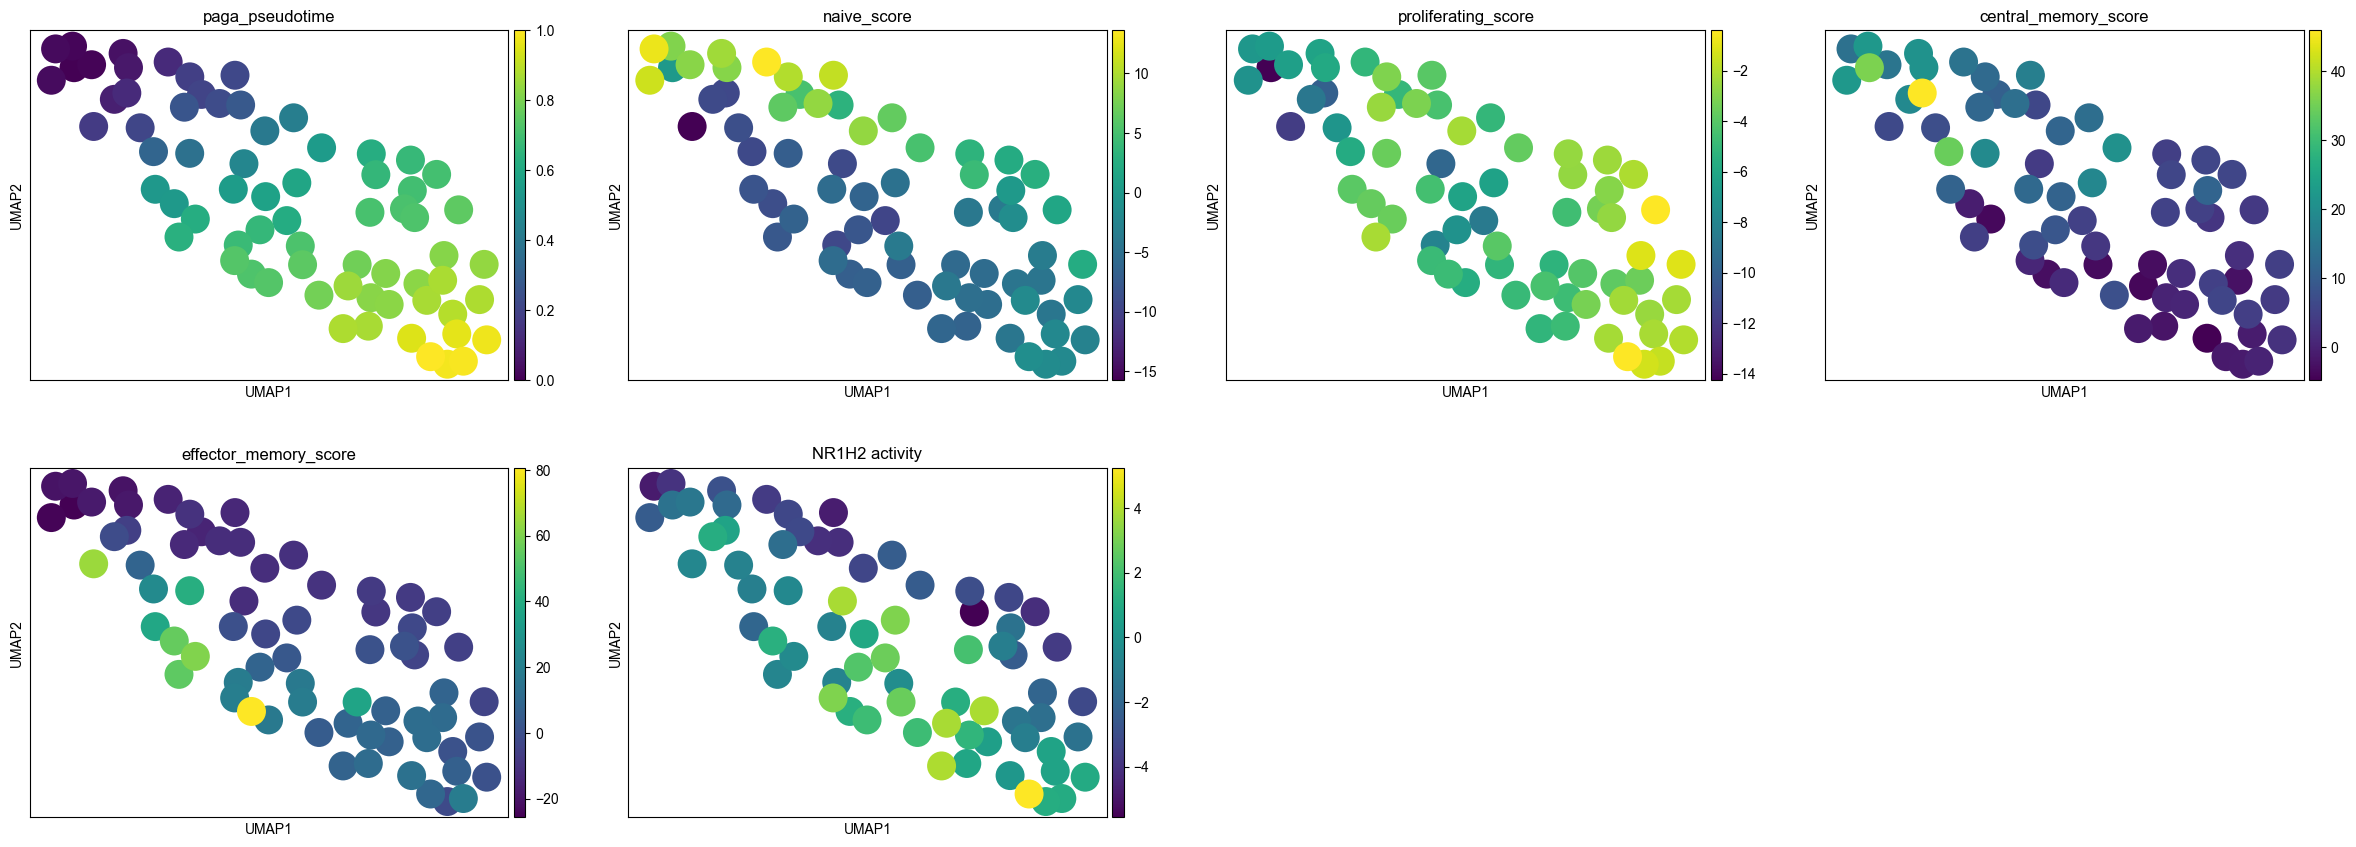

In [19]:
# only show for one group condition
unique_groups = adata_cluster.obs['group_id'].unique()
adata_plot = adata_cluster[adata_cluster.obs['group_id'] == unique_groups[0]]
assert case_TF in adata_plot.obsm['score_ulm'].columns, f"{case_TF} not found in ULM scores."
adata_plot.obs[f'{case_TF} activity'] = adata_plot.obsm['score_ulm'][case_TF]
sc.pp.neighbors(adata_plot, n_neighbors=15)
sc.tl.umap(adata_plot)
sc.pl.umap(adata_plot, color=['paga_pseudotime'] + [f'{subtype}_score' for subtype in markers.keys()] + [f'{case_TF} activity'])

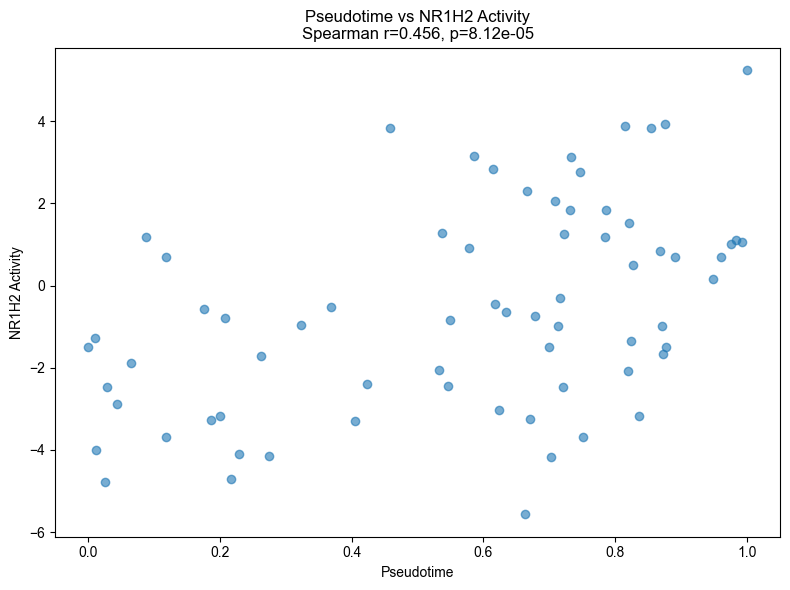

Spearman correlation: 0.456
P-value: 8.12e-05


In [20]:
from scipy.stats import spearmanr

# Display pseudotime and TF activity in a scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata_plot.obs['paga_pseudotime'], adata_plot.obs[f'{case_tf} activity'], alpha=0.6)

# Calculate Spearman correlation
corr, pval = spearmanr(adata_plot.obs['paga_pseudotime'], adata_plot.obs[f'{case_tf} activity'])

ax.set_xlabel('Pseudotime')
ax.set_ylabel(f'{case_tf} Activity')
ax.set_title(f'Pseudotime vs {case_tf} Activity\nSpearman r={corr:.3f}, p={pval:.2e}')
plt.tight_layout()
plt.show()

print(f'Spearman correlation: {corr:.3f}')
print(f'P-value: {pval:.2e}')

In [ ]:
args = lambda: None
args.dataset = 'abf300'
args.cell_type = 'CD8T'
args.test = True
adata_combined = compute_tf_activity_per_donor(args.dataset, args.cell_type, test_mode=args.test)
traj_stats = retrieve_traj_stats(args.dataset, args.cell_type, mode='dpt')

Loading data for dataset=abf300, cell_type=CD8T
Loading data...


Total cells: 388362
Unique donor_age samples: 313

=== Checking donor_age samples (min threshold: 100 cells) ===
Total donor_age samples: 313
TEST MODE: Using only 10 donors
Passing samples: 10 (>= 100 cells)
Failing samples: 0 (< 100 cells)

Filtered data: 34806 cells from 10 donor_age samples

=== Processing 10 passing donor_age samples ===


Processing donor_age samples:   0%|          | 0/10 [00:00<?, ?it/s]

Group D05_CD8T_64: Selected root cluster 7 (naive_score=0.709)


Processing donor_age samples:  10%|█         | 1/10 [00:15<02:17, 15.33s/it]

...

Group C14_CD8T_48: Selected root cluster 8 (naive_score=0.063)


Processing donor_age samples:  90%|█████████ | 9/10 [00:57<00:05,  5.46s/it]

Group A14_CD8T_32: Selected root cluster 5 (naive_score=0.174)


Processing donor_age samples: 100%|██████████| 10/10 [01:01<00:00,  6.16s/it]



=== Combining data from 10 donor_age samples ===
Combined data: 34806 observations
Age range: 25.0 - 64.0



=== Plotting Association Results ===
Plotting top 1 TFs: NR1H2


NameError: name 'dataset' is not defined

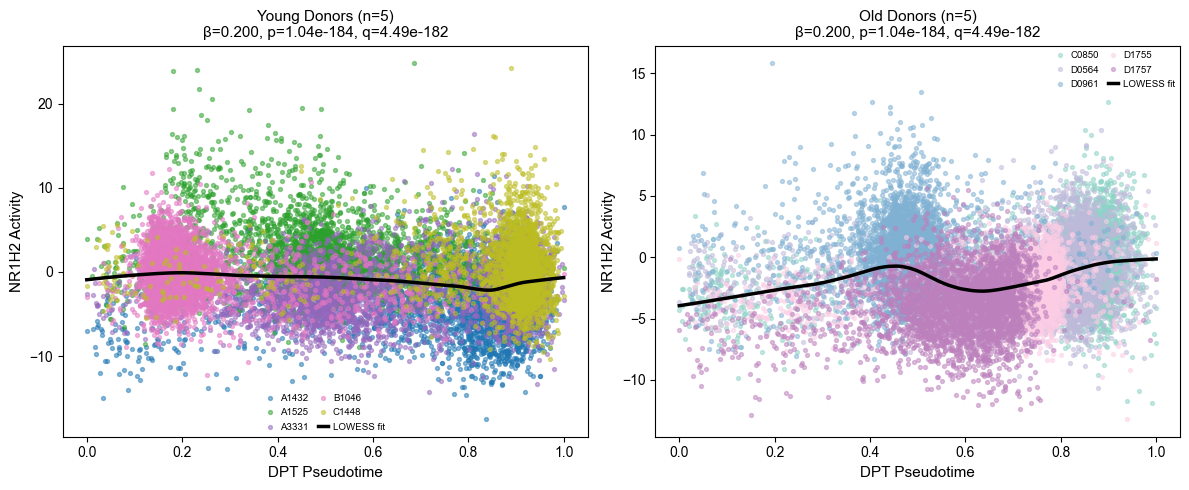

In [ ]:
top_n = 1
age_cutoff = 50
from statsmodels.nonparametric.smoothers_lowess import lowess

"""
Visualize top TFs showing altered association between TF activity and pseudotime with aging.
Shows separate scatter plots with LOWESS trend lines for young vs old donors.
"""
print(f"\n=== Plotting Association Results ===")

# Get top TFs by interaction p-value
top_tfs = traj_stats.nsmallest(top_n, 'interaction_pval')['TF'].tolist()
print(f"Plotting top {top_n} TFs: {', '.join(top_tfs)}")

# Categorize donors by age
adata_combined.obs['age_group'] = adata_combined.obs['age'].apply(
    lambda x: 'Young' if x < age_cutoff else 'Old'
)

# Create plots - 2 columns (Young, Old) for each TF
fig, axes = plt.subplots(top_n, 2, figsize=(12, 5 * top_n))
if top_n == 1:
    axes = axes.reshape(1, -1)

for idx, tf in enumerate(top_tfs):
    # Get TF activity
    tf_activity = adata_combined.obsm['score_ulm'][tf].values
    pseudotime = adata_combined.obs['paga_pseudotime'].values
    age_group = adata_combined.obs['age_group'].values
    
    # Get statistics for this TF
    tf_stats = traj_stats[traj_stats['TF'] == tf].iloc[0]
    interaction_coef = tf_stats['interaction_coef']
    interaction_pval = tf_stats['interaction_pval']
    interaction_qval = tf_stats['interaction_qval']
    
    # Plot Young and Old separately
    for col_idx, (group, base_color) in enumerate([('Young', 'blue'), ('Old', 'red')]):
        ax = axes[idx, col_idx]
        
        # Get data for this age group
        mask = age_group == group
        group_pseudotime = pseudotime[mask]
        group_tf_activity = tf_activity[mask]
        group_donor_ids = adata_combined.obs['donor_age'].values[mask]
        
        # Select 10 donors from this age group
        unique_donors = np.unique(group_donor_ids)
        selected_donors = unique_donors[:10] if len(unique_donors) >= 10 else unique_donors
        
        # Create color map for donors
        cmap = plt.cm.get_cmap('tab10' if base_color == 'blue' else 'Set3')
        donor_colors = {donor: cmap(i / len(selected_donors)) for i, donor in enumerate(selected_donors)}
        
        # Plot scatter points colored by donor
        for donor in selected_donors:
            donor_mask = group_donor_ids == donor
            ax.scatter(group_pseudotime[donor_mask], group_tf_activity[donor_mask], 
                        alpha=0.5, s=8, c=[donor_colors[donor]], label=f'{donor}')
        
        # Fit LOWESS for the entire age group (only selected donors)
        selected_mask = np.isin(group_donor_ids, selected_donors)
        if selected_mask.sum() > 10:
            sort_idx = np.argsort(group_pseudotime[selected_mask])
            sorted_pseudotime = group_pseudotime[selected_mask][sort_idx]
            sorted_tf_activity = group_tf_activity[selected_mask][sort_idx]
            
            lowess_result = lowess(sorted_tf_activity, sorted_pseudotime, 
                                    frac=0.3, return_sorted=True)
            ax.plot(lowess_result[:, 0], lowess_result[:, 1], 
                    color='black', linewidth=2.5, label='LOWESS fit', zorder=100)
        
        ax.set_xlabel('DPT Pseudotime', fontsize=11)
        ax.set_ylabel(f'{tf} Activity', fontsize=11)
        ax.set_title(f'{group} Donors (n={len(selected_donors)})\nβ={interaction_coef:.3f}, p={interaction_pval:.2e}, q={interaction_qval:.2e}', 
                    fontsize=11)
        ax.legend(fontsize=7, ncol=2, loc='best')

plt.tight_layout()
# plot_output = f"{PLOTS_DIR}/top_tf_association_{dataset}_{cell_type}.pdf"
# plt.savefig(plot_output, dpi=300, bbox_inches='tight')
# print(f"Association plot saved to: {plot_output}")
# plt.close()


=== Plotting UMAP Association Results ===
Plotting top 1 TFs: NR1H2
Young: 5 donors, 16904 cells
Old: 5 donors, 17902 cells


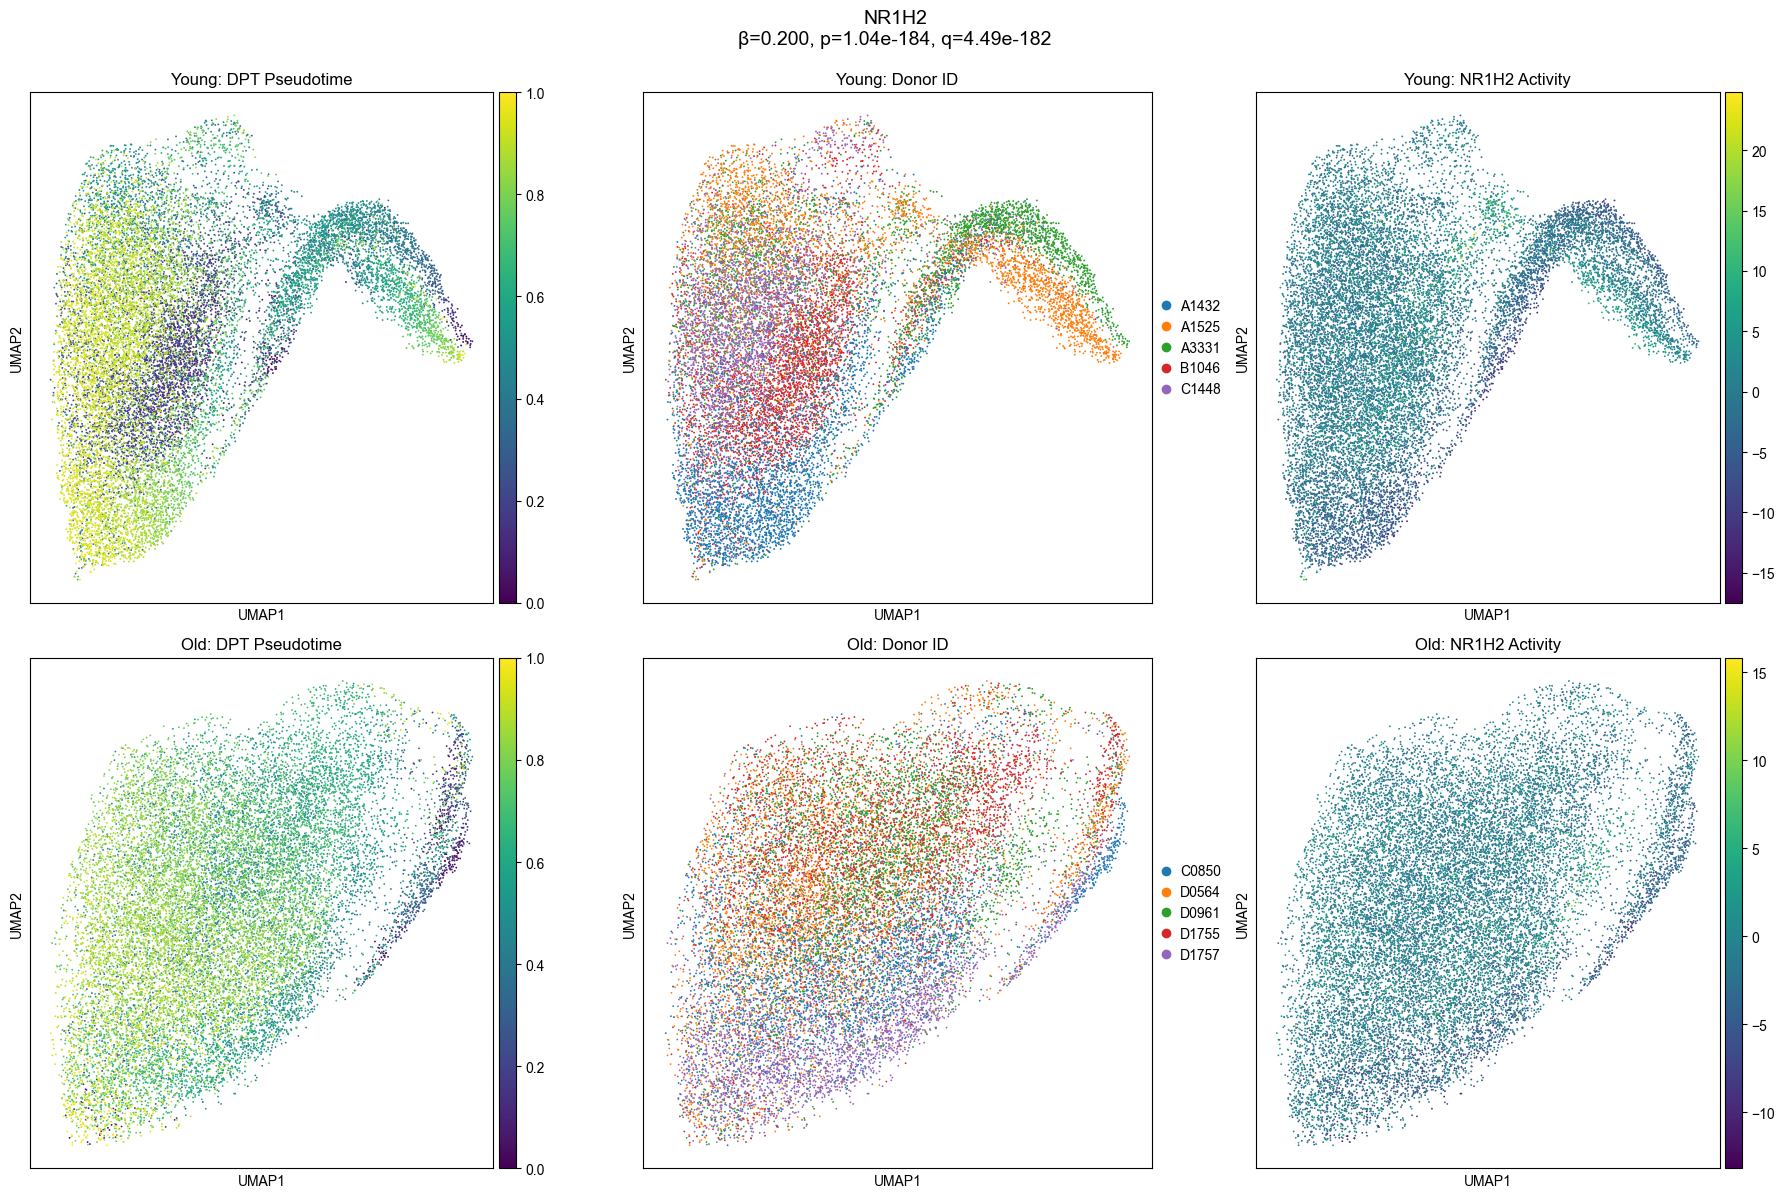

UMAP plots completed


In [14]:
top_n = 1
age_cutoff = 50

"""
Visualize top TFs showing altered association between TF activity and pseudotime with aging.
Shows UMAP plots colored by DPT, donor, and TF activity for young vs old donors.
"""
print(f"\n=== Plotting UMAP Association Results ===")

# Get top TFs by interaction p-value
top_tfs = traj_stats.nsmallest(top_n, 'interaction_pval')['TF'].tolist()
print(f"Plotting top {top_n} TFs: {', '.join(top_tfs)}")

# Categorize donors by age
adata_combined.obs['age_group'] = adata_combined.obs['age'].apply(
    lambda x: 'Young' if x < age_cutoff else 'Old'
)

for tf in top_tfs:
    # Get statistics for this TF
    tf_stats = traj_stats[traj_stats['TF'] == tf].iloc[0]
    interaction_coef = tf_stats['interaction_coef']
    interaction_pval = tf_stats['interaction_pval']
    interaction_qval = tf_stats['interaction_qval']
    
    # Add TF activity to obs
    adata_combined.obs[f'{tf}_activity'] = adata_combined.obsm['score_ulm'][tf].values
    
    # Create figure: 2 rows (Young, Old) x 3 columns (DPT, Donor, TF Activity)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for row_idx, (group, base_color) in enumerate([('Young', 'blue'), ('Old', 'red')]):
        # Filter by age group
        age_mask = adata_combined.obs['age_group'] == group
        
        # Select 10 donors from this age group
        group_donor_ids = adata_combined.obs['donor_age'].values[age_mask]
        unique_donors = np.unique(group_donor_ids)
        selected_donors = unique_donors[:10] if len(unique_donors) >= 10 else unique_donors
        
        # Get cells from selected donors
        donor_mask = adata_combined.obs['donor_age'].isin(selected_donors)
        final_mask = age_mask & donor_mask
        
        # Subset data
        adata_subset = adata_combined[final_mask].copy()
        
        print(f"{group}: {len(selected_donors)} donors, {adata_subset.n_obs} cells")
        
        # Compute UMAP
        sc.pp.neighbors(adata_subset, n_neighbors=15)
        sc.tl.umap(adata_subset)
        
        # Plot 1: DPT pseudotime
        ax = axes[row_idx, 0]
        sc.pl.umap(adata_subset, color='paga_pseudotime', ax=ax, show=False, 
                   title=f'{group}: DPT Pseudotime')
        
        # Plot 2: Donor ID
        ax = axes[row_idx, 1]
        sc.pl.umap(adata_subset, color='donor_age', ax=ax, show=False, 
                   title=f'{group}: Donor ID', legend_loc='right margin')
        
        # Plot 3: TF Activity
        ax = axes[row_idx, 2]
        sc.pl.umap(adata_subset, color=f'{tf}_activity', ax=ax, show=False, 
                   title=f'{group}: {tf} Activity')
    
    plt.suptitle(f'{tf}\nβ={interaction_coef:.3f}, p={interaction_pval:.2e}, q={interaction_qval:.2e}', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()
    
print("UMAP plots completed")